In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load data
train_df = pd.read_csv('asteroizi_train.csv', index_col='datapointID')
test_df = pd.read_csv('asteroizi_test.csv', index_col='datapointID')

train_df.head()

,X,Y,Z,Class
datapointID,,,,
11.-92734-7-5153-9845.59462205.50379-.062544069,NaN,NaN,NaN,NaN
2133109-8-.23252-,NaN,NaN,NaN,NaN
3-39.690811899155420-1565043411407,NaN,NaN,NaN,NaN
4,-0.875838,-0.133781,-0.254318,0.0
5,0.476464,0.567121,-0.587028,0.0


In [3]:
train_df.shape

(11280, 4)

# Subtask 1

In [ ]:
#The thing is that there are commas missing, so you'll have some problems if you tried to use the csv module
#But if you use pandas it won't be able to read does lines
#So you can just do .dropna()

train_df = train_df.dropna()
answer_sub1 = list(train_df['Class'].astype(int))
train_df.shape

(1280, 4)

# Subtask 2

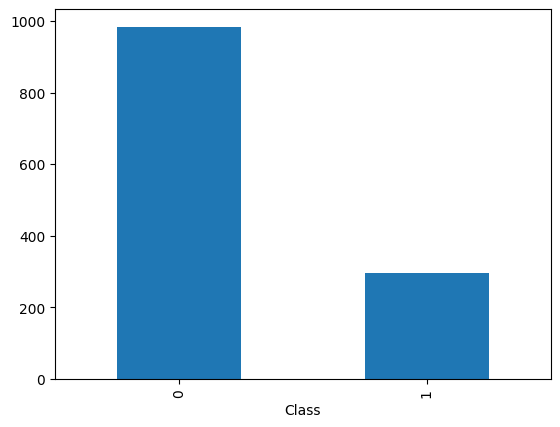

In [ ]:
X = train_df.drop('Class', axis=1)
y = train_df['Class'].astype(int)

y.value_counts().plot(kind='bar')
plt.show()

In [18]:
#Model
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score
from sklearn.preprocessing import StandardScaler

scoring = make_scorer(f1_score, pos_label=1)

model_pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('m', SVC(kernel='rbf', random_state=42))
])

param_grid = {
    'm__gamma':['auto', 'scale', 0.1, 1, 10, 15, 20],
    'm__C':[0.01, 0.1, 1, 5, 10,15],
    'm__class_weight':[None, 'balanced']
}

search = GridSearchCV(
    model_pipe, param_grid=param_grid,
    cv=5, scoring=scoring,
    n_jobs=-1, verbose=1
)

search.fit(X, y)
print('Best search score', search.best_score_)
print('Best params', search.best_params_)

best_model = search.best_estimator_

def cv_eval(model):
    cv = cross_val_score(model, X, y, cv=5, scoring=scoring, n_jobs=-1)
    return cv.mean()

print('CV eval score', cv_eval(best_model))

Fitting 5 folds for each of 84 candidates, totalling 420 fits
Best search score 0.8591896661884609
Best params {'m__C': 1, 'm__class_weight': 'balanced', 'm__gamma': 20}
CV eval score 0.8591896661884609


In [19]:
best_model.fit(X, y)
preds = best_model.predict(test_df)

output_df = pd.DataFrame({
    'subtaskID':[1] * len(X) + [2] * len(test_df),
    'datapointID':list(train_df.index) + list(test_df.index),
    'answer':answer_sub1 + list(preds)
})

output_df.head()

,subtaskID,datapointID,answer
0,1,4,0
1,1,5,0
2,1,10,0
3,1,22,0
4,1,30,1


In [ ]:
output_df.to_csv('submission.csv', index=False)

The idea here was to check the starter kit where you would find some vizualizations of the data.

Basically they showed that you can only use SVC to solve the problem and that tree-based/boosting models will fail.